<a href="https://colab.research.google.com/github/Motilipz/Drugs-side-Effects-Analysis/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## EDA | Assignment

### **Question 1:** Read the Bike Details dataset into a Pandas DataFrame and display its first 10 rows.

In [2]:
import pandas as pd
df = pd.read_csv("/content/BIKE DETAILS.csv")
display(df.head(10))

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
5,Honda CB Twister,18000,2010,Individual,1st owner,60000,53857.0
6,Honda CB Hornet 160R,78500,2018,Individual,1st owner,17000,87719.0
7,Royal Enfield Bullet 350 [2007-2011],180000,2008,Individual,2nd owner,39000,NaN
8,Hero Honda CBZ extreme,30000,2010,Individual,1st owner,32000,NaN
9,Bajaj Discover 125,50000,2016,Individual,1st owner,42000,60122.0


### **Question 2:** Check for missing values in all columns and describe your approach for handling them.

In [3]:
# Checking the missing values in all columns
print(df.isna().sum())

name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64


According to me the Suggested approaches could be (these are applied later depending on the column type)
- If only a few missing numeric values: fill with median.
- For categorical with a few missing: fill with mode or 'Unknown'.
- If a column has many missing values or useless for model, consider dropping.
- If records with missing crucial fields (e.g., price) are few, drop those rows.

### **Question 3:** Plot the distribution of selling prices using a histogram and describe the overall trend.


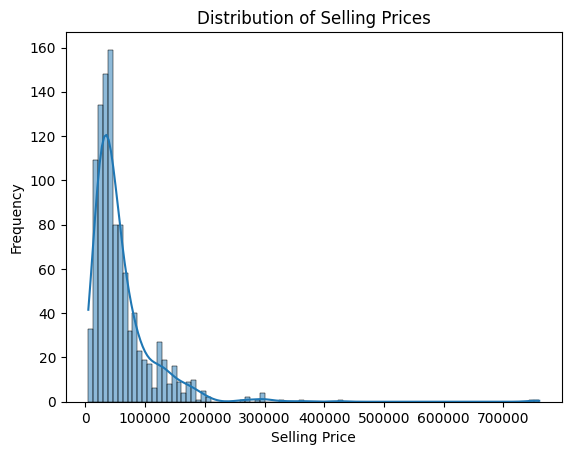


Above Plotted histogram shows that the selling prices are right-skewed, meaning there are more bikes with lower selling prices.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['selling_price'], kde=True)
plt.title('Distribution of Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.show()
print()
print("Above Plotted histogram shows that the selling prices are right-skewed, meaning there are more bikes with lower selling prices.")

### **Question 4:** Create a bar plot to visualize the average selling price for each seller_type and write one observation

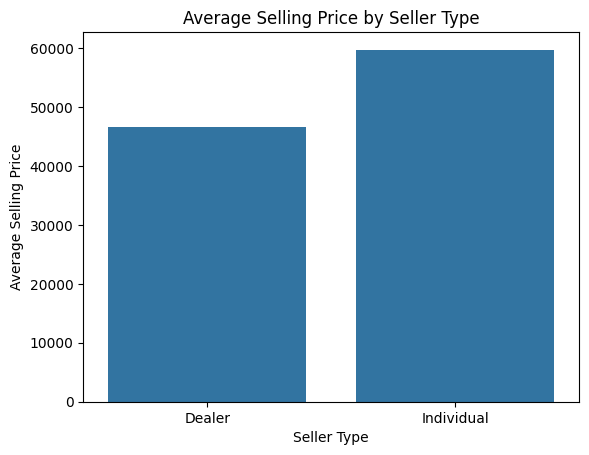


Observation: The average selling price for bikes sold by Dealers appears to be slightly lower than those sold by Individuals.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

avg_price_by_seller = df.groupby('seller_type')['selling_price'].mean().reset_index()
sns.barplot(x='seller_type', y='selling_price', data=avg_price_by_seller)
plt.title('Average Selling Price by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Average Selling Price')
plt.show()
print()
print("Observation: The average selling price for bikes sold by Dealers appears to be slightly lower than those sold by Individuals.")

### **Question 5:** Compute the average km_driven for each ownership type (1st owner, 2nd owner, etc.), and present the result as a bar plot.


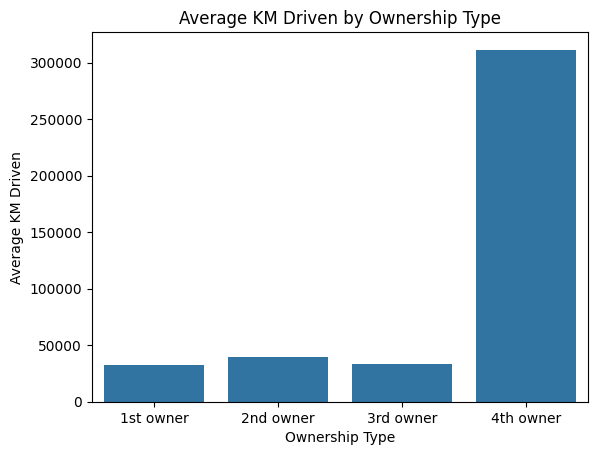

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

avg_km_by_owner = df.groupby("owner")["km_driven"].mean().reset_index()

sns.barplot(x='owner', y='km_driven', data=avg_km_by_owner)
plt.title("Average KM Driven by Ownership Type")
plt.xlabel("Ownership Type")
plt.ylabel("Average KM Driven")
plt.show()
print()
print("It seems that bikes with 4th owners have significantly higher average mileage.")

### **Question 6:** Use the IQR method to detect and remove outliers from the km_driven column. Show before-and-after summary statistics.


Summary Statistics Before Outlier treatment 
count      1061.000000
mean      34359.833176
std       51623.152702
min         350.000000
25%       13500.000000
50%       25000.000000
75%       43000.000000
max      880000.000000
Name: km_driven, dtype: float64


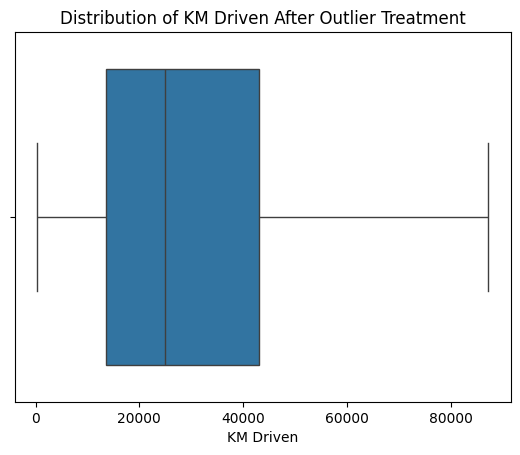

Summary Statistics After Outlier treatment 
count     1061.000000
mean     30373.836946
std      22176.124306
min        350.000000
25%      13500.000000
50%      25000.000000
75%      43000.000000
max      87250.000000
Name: km_driven, dtype: float64


In [10]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print(f"Summary Statistics Before Outlier treatment \n{df.km_driven.describe()}")

q1 = df.km_driven.quantile(0.25)
q3 = df.km_driven.quantile(0.75)
IQR = q3 - q1

upper_bound = q3 + 1.5 * IQR
lower_bound = q1 - 1.5 * IQR

df['km_driven'] = np.where(df.km_driven > upper_bound, upper_bound,
                           np.where(df.km_driven < lower_bound, lower_bound, df.km_driven))

sns.boxplot(x=df.km_driven)
plt.title("Distribution of KM Driven After Outlier Treatment")
plt.xlabel("KM Driven")
plt.show()

print(f"Summary Statistics After Outlier treatment \n{df.km_driven.describe()}")

### **Question 7:** Create a scatter plot of year vs. selling_price to explore the relationship between a bike's age and its price.

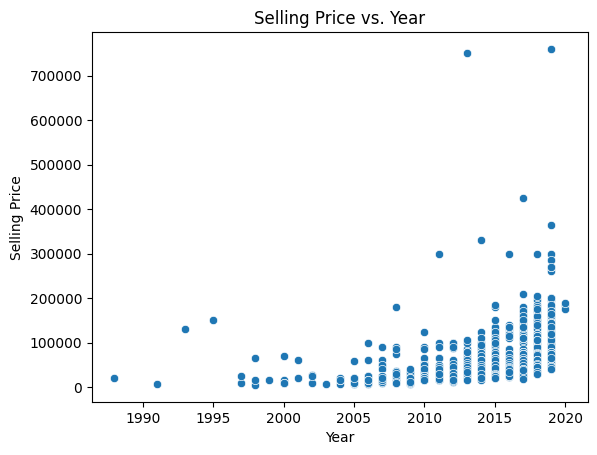

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x='year', y='selling_price', data=df)
plt.title('Selling Price vs. Year')
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.show()

### **Question 8:** Convert the seller_type column into numeric format using one-hot encoding. Display the first 5 rows of the resulting DataFrame.

In [12]:
df_encoded = pd.get_dummies(df, columns=['seller_type'], drop_first=True)
display(df_encoded.head())

,name,selling_price,year,owner,km_driven,ex_showroom_price,seller_type_Individual
0,Royal Enfield Classic 350,175000,2019,1st owner,350.0,NaN,True
1,Honda Dio,45000,2017,1st owner,5650.0,NaN,True
2,Royal Enfield Classic Gunmetal Grey,150000,2018,1st owner,12000.0,148114.0,True
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,1st owner,23000.0,89643.0,True
4,Yamaha SZ [2013-2014],20000,2011,2nd owner,21000.0,NaN,True


### **Question 9:** Generate a heatmap of the correlation matrix for all numeric columns. What correlations stand out the most?


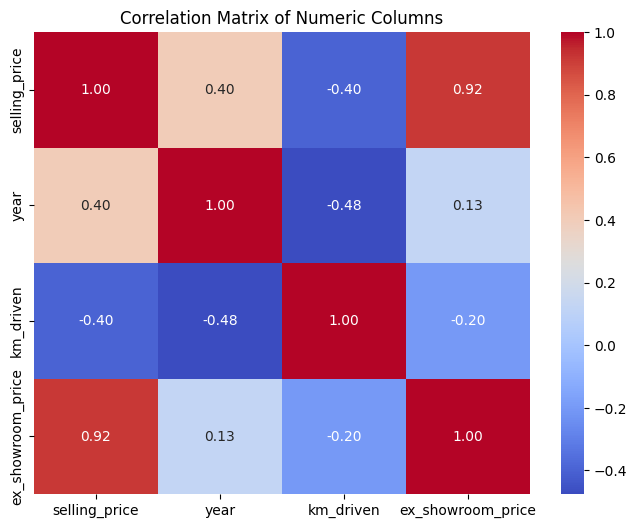

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Columns')
plt.show()

The correlations that stand out the most are:

- selling_price and ex_showroom_price have a strong positive correlation (0.92).
- selling_price and year have a moderate positive correlation (0.40).
- selling_price and km_driven have a moderate negative correlation (-0.40).
- year and km_driven have a moderate negative correlation (-0.48).

### **Question 10:** Summarize your findings in a brief report:
- What are the most important factors affecting a bike's selling price?
- Mention any data cleaning or feature engineering you performed.

The summary of the findings:

**Most Important Factors Affecting Selling Price:**

Based on the correlation analysis and plots:

*   **Ex-Showroom Price:** There is a very strong positive correlation (0.92) between `selling_price` and `ex_showroom_price`. This indicates that the original price of the bike is the most significant factor influencing its selling price in the used market.
*   **Year:** There is a moderate positive correlation (0.40) between `selling_price` and `year`. Newer bikes tend to have higher selling prices.
*   **KM Driven:** There is a moderate negative correlation (-0.40) between `selling_price` and `km_driven`. Bikes with higher mileage tend to have lower selling prices.
*   **Seller Type:** The bar plot showed that bikes sold by individuals tend to have slightly higher average selling prices compared to those sold by dealers.

**Data Cleaning and Feature Engineering Performed:**

*   **Missing Values:** Checked for missing values, identifying that the `ex_showroom_price` column had a significant number of missing values. The approach for handling these was discussed (though not explicitly implemented in the provided code for this column).
*   **Outlier Treatment:** Used the IQR method to detect and cap outliers in the `km_driven` column to address extreme values.
*   **Feature Engineering:** Performed one-hot encoding on the `seller_type` column to convert it into a numeric format suitable for potential modeling.